# Causal Entropic Forces

Here's how the algorithm works:
1. From the current state, sample `NUM_ROLLOUTS`
2. Estimate the probability of sampling trajectory i `p(traj_i)` using kernel density estimation
3. Define the volume of trajectory i as `vol_i = 1 / p(traj_i)`
4. Calculate the normalized volume of a trajectory `norm_vol_i = vol_i / \sum_i vol_i`
5. Calculate the causal entropic force `2 * T_C / T_R \mean_i f_i * \log norm_vol_i`, where `f_i` is the initial force of trajectory i and the value `T_C / T_R` governs how much more you want to exploit (acting following the entropic force) vs explore (sampling a trajectory)
6. Use the causal entropic force to update the current state

In [1]:
import numpy as np

import scipy

from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import cm

import copy
import time
import datetime

In [2]:
np.random.seed(0)

dtype = np.float32

## Hyperparameters

In [3]:
T_R     = 4e5  # temperature of random agent (K)
T_C     = 2e6  # temperature of causal agent (K)
TAU     = 10.  # simulation time horizon (seconds)
EPSILON = .025 # timesteps (seconds)

In [4]:
NUM_ROLLOUTS = 100

In [5]:
NUM_SUBSAMPLES = 3

In [6]:
CHUNK_SIZE = 5000

## Particle-in-a-box environment and dynamics

In [7]:
M     = 1e-21                             # mass (kg)
L     = 400                               # length (meters) 
Q_MIN = np.array([0., 0.  ], dtype=dtype) # minimum box displacements
Q_MAX = np.array([L , L/5.], dtype=dtype) # maximum box displacements

In [8]:
def step_p(p, f):
    p     = f * EPSILON
    p_max = M * np.abs(Q_MAX - Q_MIN) / EPSILON
    new_p = np.sign(p) * np.minimum(p_max, np.abs(p))
    return new_p

In [9]:
def step_q(q, p, new_p):
    new_q = q  +  .5 * EPSILON * (p + new_p) / M
    return new_q

In [10]:
def enforce_elastic_collisions(p, q):
    q  = np.maximum(q, 2 * Q_MIN - q)
    p *= np.sign(q - Q_MIN)
    q  = np.minimum(q, 2 * Q_MAX - q)
    p *= np.sign(Q_MAX - q)
    return p, q

In [11]:
def step_phase_space(p, q, f):
    new_p        = step_p(p, f)
    new_q        = step_q(q, p, new_p)
    new_p, new_q = enforce_elastic_collisions(new_p, new_q)
    return new_p, new_q

## Random rollouts

In [12]:
timesteps = int(TAU / EPSILON)

In [13]:
def generate_fs(num_samples):
    # scale calculation formula from https://math.stackexchange.com/a/1426406
    return np.random.normal( loc   = 0. ,
                             scale = np.sqrt(M * scipy.constants.Boltzmann * T_R) / EPSILON ,
                             size  = (num_samples, 2) ).astype(dtype)

In [14]:
def rollouts(p, q, num_samples):
    """
    paths.shape = (timesteps, num_samples, q_dim)
    """
    ps = np.tile(p[None, :], (num_samples, 1))
    qs = np.tile(q[None, :], (num_samples, 1))

    paths = copy.deepcopy(qs[None, :])

    fs       = generate_fs(num_samples)
    first_fs = copy.deepcopy(fs)
    
    for i in range(timesteps):
        ps, qs = step_phase_space(ps, qs, fs)
        paths  = np.append(paths, qs[None, :], axis=0)
        fs     = generate_fs(num_samples)

    return paths, first_fs

## Causal Entropic Forcing

In [15]:
def subsample(paths):
    # idea and code from Google Gemini to speed up KDE
    sub_indices = np.linspace( 0 ,
                               timesteps - 1 ,
                               NUM_SUBSAMPLES ,
                               dtype=np.int32 ) 
    sub_paths = paths[sub_indices, :, :]
    return sub_paths

In [16]:
# The following code is modified from 
# [1]: https://github.com/scipy/scipy/blob/main/scipy/stats/_kde.py
# [2]: https://github.com/scipy/scipy/blob/main/scipy/stats/_stats.pyx#L744
# [3]: code generated by Google Gemini Flash 3.6 to implement gaussian kde
# with diagonal bandwidth matrix (the idea to use a diagonal kernel was also
# suggested by Google Gemini Flash 3.6)
# 
# [1] has a copyright notice which I have reproduced below
# 
# -------------------------------------------------------------------------------
#
#  Define classes for (uni/multi)-variate kernel density estimation.
#
#  Currently, only Gaussian kernels are implemented.
#
#  Written by: Robert Kern
#
#  Date: 2004-08-09
#
#  Modified: 2005-02-10 by Robert Kern.
#              Contributed to SciPy
#            2005-10-07 by Robert Kern.
#              Some fixes to match the new scipy_core
#
#  Copyright 2004-2005 by Enthought, Inc.
#
# -------------------------------------------------------------------------------


def diag_gaussian_kde_logpdfs(dataset, subsampling=True, chunk_size=CHUNK_SIZE):
    d, m = dataset.shape
    
    std_per_dim = np.std(dataset, axis=1, keepdims=True)
    scotts_factor = np.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T.astype(dtype)

    # all in one go
    # arg = np.sum((dataset_ - dataset_[:, None]) ** 2., axis=-1)
    # log_pdfs = scipy.special.logsumexp(-arg/2., axis=1)
    
    # naive loop
    log_pdfs = np.zeros(m)
    for j in range(m):
        arg = np.sum((dataset_ - dataset_[j, :]) ** 2., axis=-1)
        log_pdfs[j] = scipy.special.logsumexp(-arg/2.)

    # chunking
    # log_pdfs = np.zeros(m)
    # for j in range(0, m, chunk_size):
    #     arg = np.sum((dataset_ - dataset_[j : j+chunk_size][:, None]) ** 2., axis=-1)
    #     log_pdfs[j : j+chunk_size] = scipy.special.logsumexp(-arg/2., axis=1)

    # scipy function
    # arg = scipy.spatial.distance.cdist(dataset_, dataset_, 'sqeuclidean')
    # log_pdfs = scipy.special.logsumexp(-arg/2., axis=1)

    return log_pdfs

In [17]:
def log_vol_fracs(dataset, subsampling=True):
    if subsampling:
        dataset = subsample(dataset[1:])
    dataset = dataset.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)
    
    log_pdfs = diag_gaussian_kde_logpdfs(dataset)
    log_omega = -log_pdfs
    log_volume_fracs = log_omega - scipy.special.logsumexp(log_omega)
    return log_volume_fracs

In [18]:
def entropic_force(p, q):
    paths, fs = rollouts(p, q, NUM_ROLLOUTS)
    return np.mean( fs * log_vol_fracs(paths)[:, None] , axis=0 )

## Rollouts

In [19]:
import jax

from jax import numpy as jnp

def diag_gaussian_kde_logpdfs_jax(dataset, subsampling=True, chunk_size=CHUNK_SIZE):
    d, m = dataset.shape
    
    std_per_dim = jnp.std(dataset, axis=1, keepdims=True)
    scotts_factor = jnp.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T

    log_pdfs = jnp.zeros(m)
    for j in range(0, m, chunk_size):
        arg = jnp.sum((dataset_ - dataset_[j : j+chunk_size][:, None]) ** 2., axis=-1)
        log_pdfs = log_pdfs.at[j : j+chunk_size].set(jax.scipy.special.logsumexp(-arg/2., axis=1))
    
    return log_pdfs

In [20]:
p = np.array([0.   , 0.   ])
q = np.array([L/10., L/10.])

In [21]:
paths, fs = rollouts(p, q, NUM_ROLLOUTS)

In [22]:
paths.shape

(401, 100, 2)

In [23]:
paths, fs = rollouts(p, q, NUM_ROLLOUTS)
paths = subsample(paths[1:])
flat_paths = paths.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)

In [24]:
log_pdfs_jnp = diag_gaussian_kde_logpdfs_jax(flat_paths)
log_omega = -log_pdfs_jnp
log_volume_fracs_jnp = log_omega - scipy.special.logsumexp(log_omega)

Platform 'mps' is experimental and not all JAX functionality may be correctly supported!
[jax-mps] Tip: set JAX_MPS_ASYNC_DISPATCH=1 to opt into async dispatch (experimental; can be much faster for dispatch-bound workloads).


In [25]:
log_pdfs_np = diag_gaussian_kde_logpdfs(flat_paths)
log_omega = -log_pdfs_np
log_volume_fracs_np = log_omega - scipy.special.logsumexp(log_omega)

In [26]:
log_pdfs_scipy = scipy.stats.gaussian_kde(flat_paths).logpdf(flat_paths)
log_omega = -log_pdfs_scipy
log_volume_fracs_scipy = log_omega - scipy.special.logsumexp(log_omega)

In [35]:
log_volume_fracs_jnp - log_volume_fracs_jnp.mean()

Array([-0.17707872, -0.10897064, -0.12772274,  0.2560892 ,  0.09127331,
       -0.15729904, -0.19234848, -0.57526064, -0.20745754, -0.12522602,
        0.28964424,  0.13924742, -0.5330243 ,  0.0628171 ,  0.20630741,
       -0.48572206,  0.05169725, -0.11434031,  0.31456137, -0.1795001 ,
       -0.02612495,  0.2902832 , -0.20459127, -0.34440756,  0.33679104,
       -0.13456392, -0.18835354,  0.0454154 ,  0.24131203, -0.0359025 ,
        0.28362417,  0.16564655,  0.1679802 , -0.08107853,  0.31746912,
        0.18189478,  0.19054079, -0.07197428,  0.07612944,  0.07793999,
       -0.44691658, -0.15871334, -0.09335661,  0.35597515, -0.05411816,
       -0.03508854,  0.27330446,  0.35646772,  0.0014596 , -0.10006618,
        0.2687397 ,  0.17569637, -0.47976112,  0.32767582,  0.25570822,
        0.3564391 , -0.53279734,  0.2537179 ,  0.29669333,  0.17060184,
       -0.16535902, -0.1994462 , -0.477808  ,  0.25656605, -0.3129902 ,
       -0.00348425,  0.0765295 ,  0.30842638, -0.21513844,  0.24

In [27]:
jnp.abs(log_volume_fracs_jnp - log_volume_fracs_np).mean()

Array(4.053116e-07, dtype=float32)

In [28]:
jnp.abs(log_volume_fracs_jnp - log_volume_fracs_scipy).mean()

Array(0.06165988, dtype=float32)

In [29]:
np.corrcoef(log_volume_fracs_jnp, log_volume_fracs_scipy)

array([[1.        , 0.95910405],
       [0.95910405, 1.        ]])

In [30]:
np.corrcoef(log_volume_fracs_jnp, log_volume_fracs_np)

array([[1., 1.],
       [1., 1.]])

In [31]:
np.corrcoef(log_volume_fracs_scipy, log_volume_fracs_np)

array([[1.        , 0.95910396],
       [0.95910396, 1.        ]])

In [32]:
p = np.array([0.   , 0.   ])
q = np.array([L/10., L/10.])

path = copy.deepcopy(q[None, :])

start_time = time.time()
for timestep in range(100):
    elapsed_time = time.time() - start_time
    print(timestep, datetime.timedelta(seconds=int(elapsed_time)), q)
    
    f_c  = 2. * T_C / T_R * entropic_force(p, q)
    p, q = step_phase_space(p, q, f_c)
    path = np.append(path, q[None, :], axis=0)

0 0:00:00 [40. 40.]
1 0:00:00 [36.9141903 39.6149047]
2 0:00:00 [36.23349281 44.56897697]
3 0:00:00 [37.22838481 55.82459011]
4 0:00:00 [38.08831385 64.13007862]
5 0:00:00 [46.5222687  64.32153695]
6 0:00:00 [57.73532296 63.68280185]
7 0:00:00 [64.11533707 55.4202301 ]
8 0:00:00 [65.38856956 40.41838659]
9 0:00:00 [64.10501271 32.59693076]
10 0:00:00 [64.55729513 20.97728022]
11 0:00:00 [64.41497998  9.92909967]
12 0:00:00 [62.42314918  6.80936802]
13 0:00:00 [64.44297461  5.23819438]
14 0:00:00 [70.22490186  2.44868636]
15 0:00:00 [71.66496941  8.95993105]
16 0:00:00 [65.95941504 15.15890934]
17 0:00:00 [59.07734262 15.12962628]
18 0:00:00 [57.14962854 17.20774383]
19 0:00:00 [57.94102235 15.29075632]
20 0:00:00 [57.53226657 16.19454456]
21 0:00:00 [55.51555289 17.92538112]
22 0:00:00 [54.57841807 14.15679169]
23 0:00:00 [57.93734283 12.60475374]
24 0:00:00 [60.18533439 12.07144957]
25 0:00:00 [60.44452171  8.89663506]
26 0:00:00 [64.37506246 10.38264258]
27 0:00:00 [70.06680376 10.78

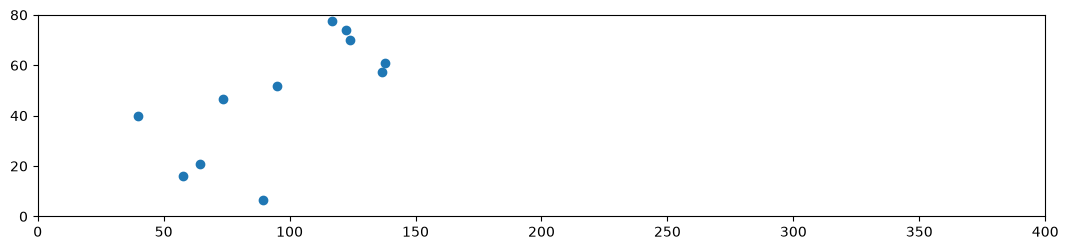

In [33]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.scatter(*path[::10].T)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect='equal')
plt.show()